In [6]:
import pandas as pd
from gqlalchemy import Memgraph
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

feature_names = [
    "tx_amount", "tx_velocity_1h", "fan_out_degree", "fan_in_degree",
    "pagerank_score", "betweenness_centrality", "louvain_community_id",
    "avg_hop_distance", "account_age_days", "cross_border_flag",
    "device_risk_score", "ip_entropy"
]

def load_data():
    try:
        memgraph = Memgraph(host="127.0.0.1", port=7687)
        # Fetch properties explicitly from node/relationship maps
        query = """
        MATCH (a:Account)-[t:TRANSACTION]->(b:Account)
        RETURN 
            coalesce(t.amount, 0.0) AS tx_amount,
            coalesce(a.velocity_1h, 0.0) AS tx_velocity_1h,
            coalesce(a.fan_out, 0) AS fan_out_degree,
            coalesce(a.fan_in, 0) AS fan_in_degree,
            coalesce(a.pagerank, 0.0) AS pagerank_score,
            coalesce(a.betweenness, 0.0) AS betweenness_centrality,
            coalesce(a.community_id, 0) AS louvain_community_id,
            coalesce(a.avg_hop, 0.0) AS avg_hop_distance,
            coalesce(a.age_days, 0) AS account_age_days,
            coalesce(t.is_cross_border, 0) AS cross_border_flag,
            coalesce(a.device_risk, 0.0) AS device_risk_score,
            coalesce(a.ip_entropy, 0.0) AS ip_entropy,
            coalesce(t.is_fraud, 0) AS is_fraud
        """
        results = list(memgraph.execute_and_fetch(query))
        
        if len(results) > 0:
            df = pd.DataFrame(results)
            # Normalize dictionary results if returned as mgclient objects
            if isinstance(results[0], dict) and 'is_fraud' in df.columns:
                print("Successfully loaded transaction feature matrix from Memgraph.")
                return df
                
        print("Memgraph query returned empty or unparseable graph records. Generating synthetic data...")
    except Exception as e:
        print(f"Could not connect or query Memgraph ({e}). Generating synthetic benchmark data...")

    # Fallback to balanced/synthetic data generation
    X, y = make_classification(
        n_samples=5000, n_features=12, n_informative=8, n_redundant=2,
        weights=[0.97, 0.03], random_state=42
    )
    df = pd.DataFrame(X, columns=feature_names)
    df['is_fraud'] = y
    return df

df_features = load_data()

X = df_features[feature_names]
y = df_features['is_fraud'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {len(X_train)} transactions | Test Set: {len(X_test)} transactions")
print(f"Fraud distribution: {y.sum()} fraudulent / {len(y) - y.sum()} legitimate")

Memgraph query returned empty or unparseable graph records. Generating synthetic data...
Training Set: 4000 transactions | Test Set: 1000 transactions
Fraud distribution: 172 fraudulent / 4828 legitimate


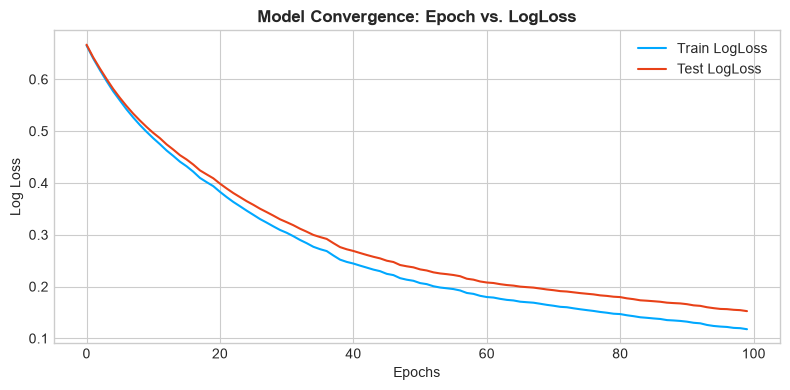

In [7]:
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    eval_metric=["logloss", "auc"],
    random_state=42
)

eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_axis, results['validation_0']['logloss'], label='Train LogLoss', color='#00a8ff')
ax.plot(x_axis, results['validation_1']['logloss'], label='Test LogLoss', color='#e84118')
ax.set_title('Model Convergence: Epoch vs. LogLoss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epochs')
ax.set_ylabel('Log Loss')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

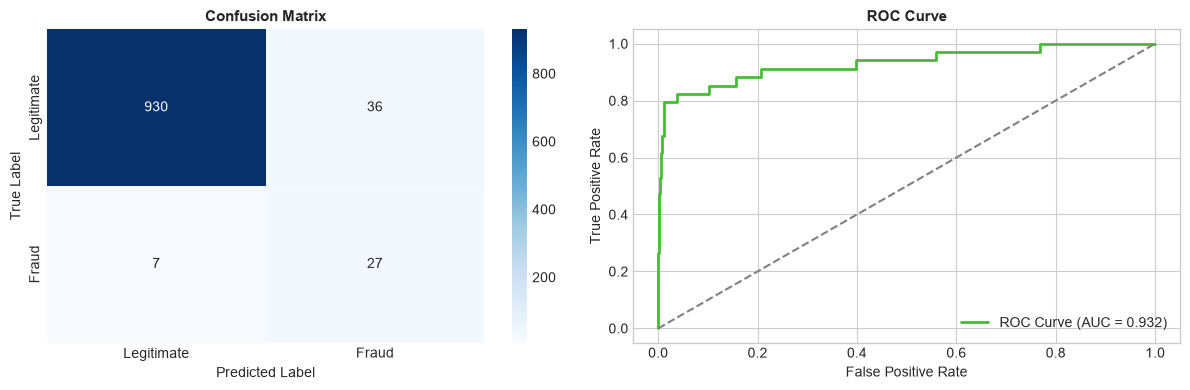


--- Detailed Classification Report ---
              precision    recall  f1-score   support

  Legitimate       0.99      0.96      0.98       966
       Fraud       0.43      0.79      0.56        34

    accuracy                           0.96      1000
   macro avg       0.71      0.88      0.77      1000
weighted avg       0.97      0.96      0.96      1000



In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Confusion Matrix', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#44bd32', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve', fontsize=11, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

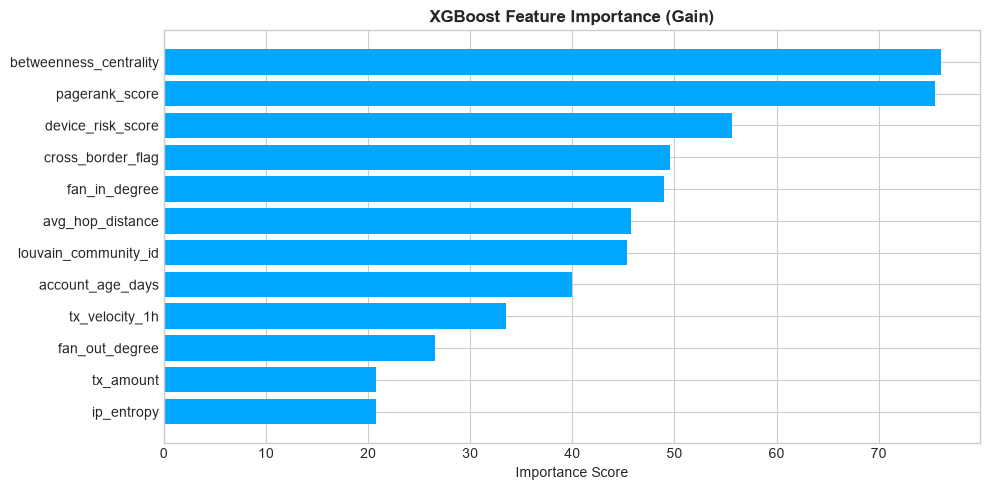

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importance by Gain directly from XGBoost
importance = model.get_booster().get_score(importance_type='gain')
df_imp = pd.DataFrame(list(importance.items()), columns=['feature', 'importance']).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_imp['feature'], df_imp['importance'], color='#00a8ff')
plt.title('XGBoost Feature Importance (Gain)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.datasets import make_classification
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
print("Environment initialized successfully.")


Environment initialized successfully.


c:\Users\Hp\fraudnet-zero\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
